# 🦠 COVID-19 Global Analysis — Mid 2020
**Author:** Adeesha Akeeth 
**Tools:** Python, Pandas, Numpy, Matplotlib

## Project Overview
This project analyzes COVID-19 data from mid-2020 across 187 countries,
uncovering global trends in confirmed cases, death rates, recovery rates,
and regional impacts using real WHO data.

## Important Note
This dataset represents a snapshot from mid-2020, early in the pandemic.
Final cumulative totals are significantly higher.

## Key Questions Answered
1. Which countries had the most confirmed cases?
2. Which countries had the highest death rates?
3. Which countries had the best recovery rates?
4. Which WHO region was hit hardest?
5. How did Sri Lanka perform globally? 🇱🇰

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('.\country_wise_latest.csv')

In [4]:
print("Dataset loaded successfully!")
print("Shape:",df.shape)

Dataset loaded successfully!
Shape: (187, 15)


In [5]:
print(df.columns)

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [7]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [8]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [30]:
confirmed = np.array(df['Confirmed'])
deaths = np.array(df['Deaths'])
recovered = np.array(df['Recovered'])

print(f"=== Global COVID Statistics ===")
print(f"Total Confirmed Cases: {confirmed.sum():,}")
print(f"Total deaths : {deaths.sum():,}")
print(f"Total recovered: {recovered.sum():,}")
print(f"Average cases per country : {confirmed.mean():,.0f}")
print(f"Median cases per country : {np.median(confirmed):,.0f}")
print(f"Highest Cases (single country): {confirmed.max():,}")
print(f"Lowest Cases (single country): {confirmed.min():,}")

=== Global COVID Statistics ===
Total Confirmed Cases: 16,480,485
Total deaths : 654,036
Total recovered: 9,468,087
Average cases per country : 88,131
Median cases per country : 5,059
Highest Cases (single country): 4,290,259
Lowest Cases (single country): 10


## Q1 — Top 10 Countries by Confirmed Cases
The USA led with 4.2 million cases in mid-2020, nearly double 
second place Brazil. A small number of countries dominated global case counts.

In [32]:
top10_confirmed = df[['Country/Region','Confirmed']].sort_values(by = 'Confirmed', ascending = False).head(10)
print(top10_confirmed)

     Country/Region  Confirmed
173              US    4290259
23           Brazil    2442375
79            India    1480073
138          Russia     816680
154    South Africa     452529
111          Mexico     395489
132            Peru     389717
35            Chile     347923
177  United Kingdom     301708
81             Iran     293606


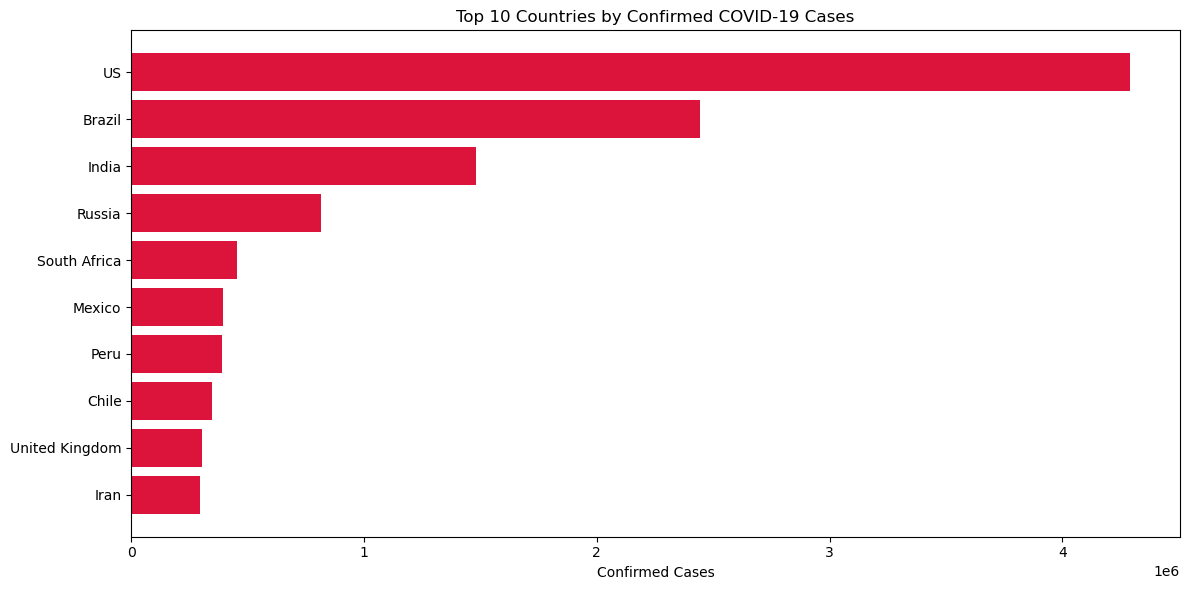

In [39]:
plt.figure(figsize = (12,6))
plt.barh(top10_confirmed['Country/Region'], top10_confirmed['Confirmed'], color = 'crimson')
plt.gca().invert_yaxis()
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel('Confirmed Cases')
plt.tight_layout()
plt.show()

## Q2 — Top 10 Countries by Death Rate
Yemen had a shocking 28.56% death rate due to a collapsed healthcare system.
High case counts don't always mean high death rates.

In [40]:
top10_death_rate = df[['Country/Region','Deaths / 100 Cases']].sort_values(by = 'Deaths / 100 Cases', ascending = False).head(10)
print(top10_death_rate)

     Country/Region  Deaths / 100 Cases
184           Yemen               28.56
177  United Kingdom               15.19
16          Belgium               14.79
85            Italy               14.26
61           France               13.71
77          Hungary               13.40
120     Netherlands               11.53
111          Mexico               11.13
157           Spain               10.44
183  Western Sahara               10.00


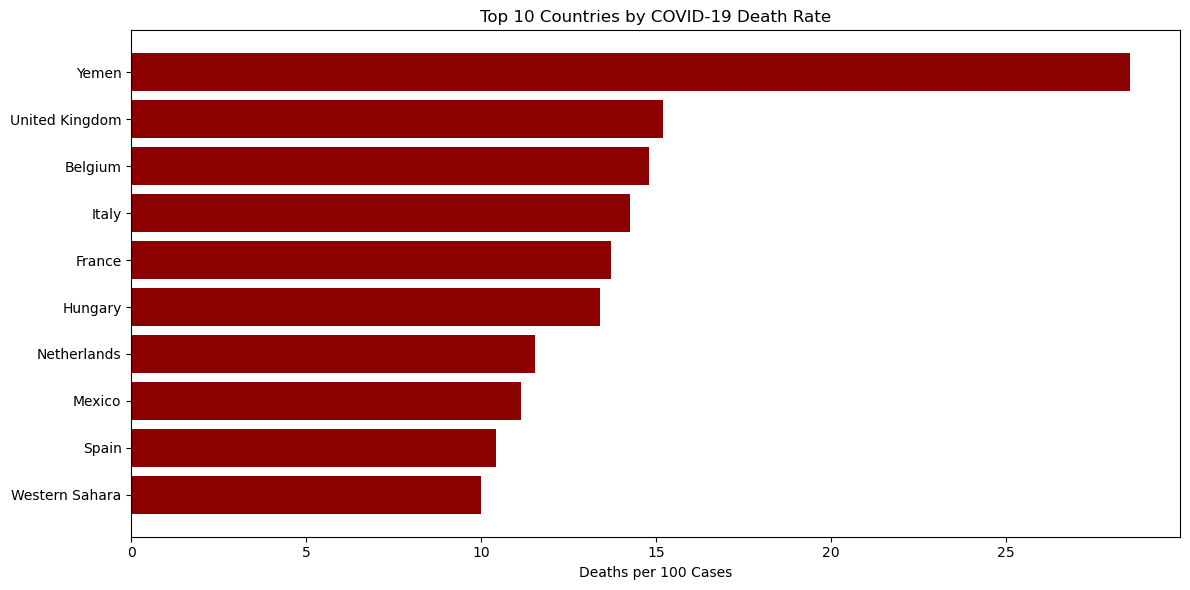

In [48]:
plt.figure(figsize = (12,6))
plt.barh(top10_death_rate['Country/Region'],top10_death_rate['Deaths / 100 Cases'], color = 'darkred')
plt.gca().invert_yaxis()
plt.title('Top 10 Countries by COVID-19 Death Rate')
plt.xlabel('Deaths per 100 Cases')
plt.tight_layout()
plt.show()

## Q3 — Top 10 Countries by Recovery Rate
Filtered to countries with minimum 1000 cases for meaningful comparison.
Djibouti and Iceland led with 98%+ recovery rates.

In [46]:
top10_recovery = df[['Country/Region', 'Recovered / 100 Cases']].sort_values(
    by='Recovered / 100 Cases', ascending=False).head(10)

print(top10_recovery)

    Country/Region  Recovered / 100 Cases
75        Holy See                 100.00
69         Grenada                 100.00
49        Dominica                 100.00
48        Djibouti                  98.38
78         Iceland                  98.33
24          Brunei                  97.87
121    New Zealand                  97.24
136          Qatar                  97.02
105       Malaysia                  96.60
110      Mauritius                  96.51


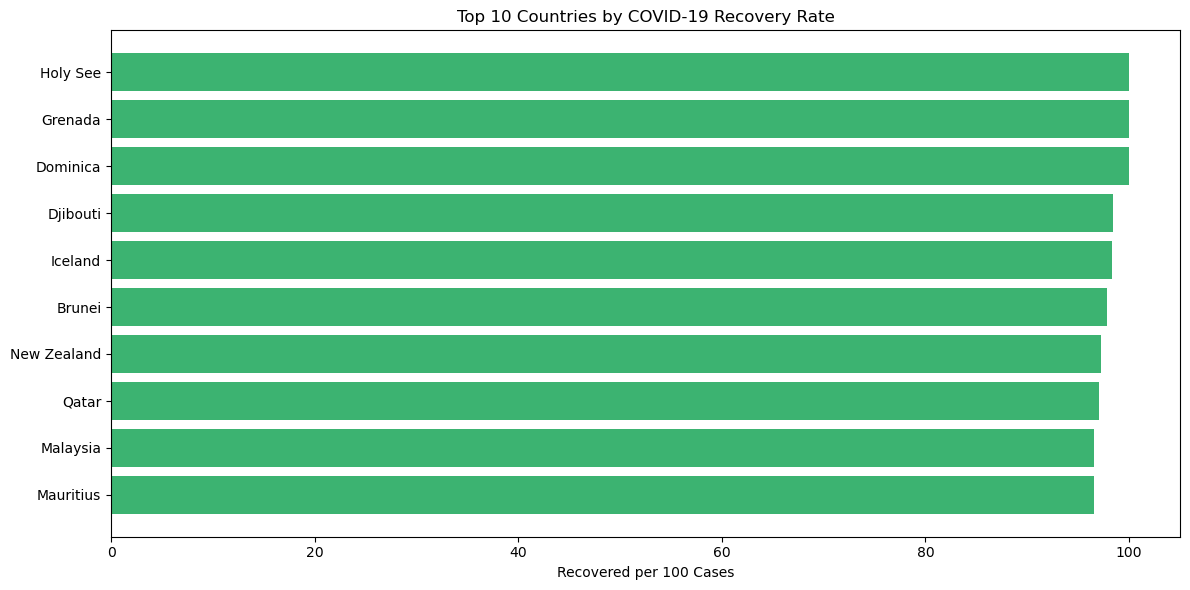

In [47]:
plt.figure(figsize=(12, 6))
plt.barh(top10_recovery['Country/Region'], top10_recovery['Recovered / 100 Cases'], color='mediumseagreen')
plt.xlabel('Recovered per 100 Cases')
plt.title('Top 10 Countries by COVID-19 Recovery Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [51]:
top10_recovery_filtered = df[df['Confirmed']>=1000][['Country/Region','Recovered / 100 Cases']].sort_values(by = 'Recovered / 100 Cases',ascending = False).head(10)
print(top10_recovery_filtered.head())

    Country/Region  Recovered / 100 Cases
48        Djibouti                  98.38
78         Iceland                  98.33
121    New Zealand                  97.24
136          Qatar                  97.02
105       Malaysia                  96.60


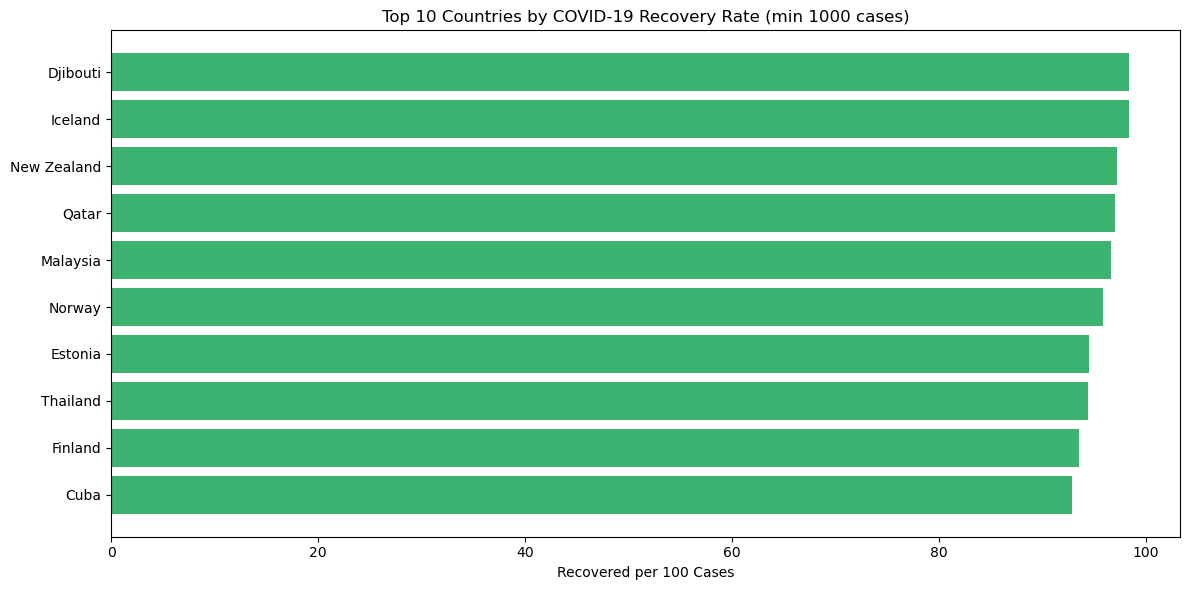

In [52]:
plt.figure(figsize=(12, 6))
plt.barh(top10_recovery_filtered['Country/Region'], top10_recovery_filtered['Recovered / 100 Cases'], color='mediumseagreen')
plt.xlabel('Recovered per 100 Cases')
plt.title('Top 10 Countries by COVID-19 Recovery Rate (min 1000 cases)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q3 — Top 10 Countries by Recovery Rate
Initial analysis showed small territories like Holy See, Grenada and Dominica 
at 100% recovery — but with very few cases, percentages are misleading.

After filtering to countries with minimum 1000 confirmed cases, more meaningful 
results emerged. Djibouti and Iceland led with 98%+ recovery rates, followed 
by New Zealand, Qatar and Malaysia — all countries known for strong healthcare 
responses and early lockdown measures.

In [77]:
who_region = df.groupby(df['WHO Region']).agg({
    'Confirmed' : 'sum',
    'Deaths' : 'sum',
    'Recovered' : 'sum'
}).reset_index()

who_region['Death Rate %'] = ((who_region['Deaths']/who_region['Confirmed'])*100).round(2)

who_region = who_region.sort_values(by = 'Confirmed', ascending = False)

In [78]:
print(who_region)

              WHO Region  Confirmed  Deaths  Recovered  Death Rate %
1               Americas    8839286  342732    4468616          3.88
3                 Europe    3299523  211144    1993723          6.40
4        South-East Asia    1835297   41349    1156933          2.25
2  Eastern Mediterranean    1490744   38339    1201400          2.57
0                 Africa     723207   12223     440645          1.69
5        Western Pacific     292428    8249     206770          2.82


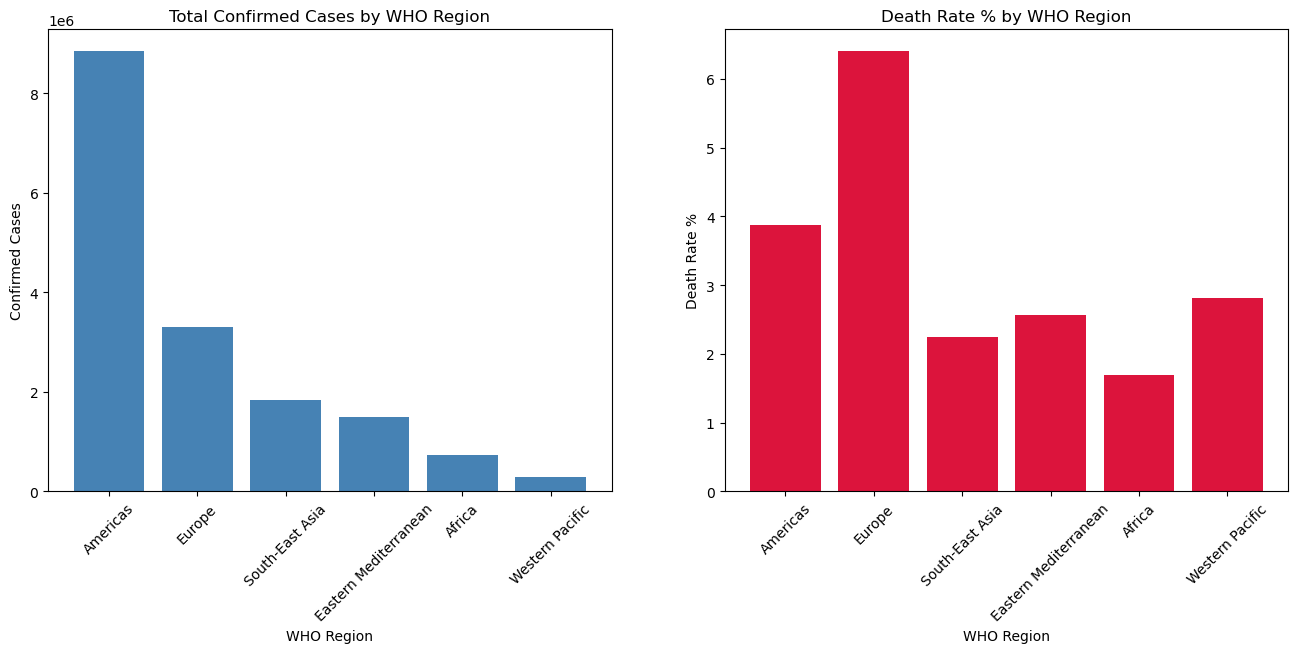

In [95]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (16,6))

ax1.bar(who_region['WHO Region'],who_region['Confirmed'], color = 'steelblue')
ax1.set_title('Total Confirmed Cases by WHO Region')
ax1.set_xlabel('WHO Region')
ax1.set_ylabel('Confirmed Cases')
ax1.tick_params(axis = 'x', rotation = 45)

ax2.bar(who_region['WHO Region'],who_region['Death Rate %'], color = 'crimson')
ax2.set_title('Death Rate % by WHO Region')
ax2.set_xlabel('WHO Region')
ax2.set_ylabel('Death Rate %')

ax2.tick_params(axis = 'x', rotation = 45)

## Q5 — Sri Lanka's Global Position 🇱🇰
Sri Lanka achieved a death rate of just 0.39% compared to the global 
average of ~4% — performing 10x better than the world average in mid-2020.

In [88]:
sri_lanka = df[df['Country/Region']=='Sri Lanka']
print(sri_lanka[['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 
                  'Deaths / 100 Cases', 'Recovered / 100 Cases', 'WHO Region']])

    Country/Region  Confirmed  Deaths  Recovered  Deaths / 100 Cases  \
158      Sri Lanka       2805      11       2121                0.39   

     Recovered / 100 Cases       WHO Region  
158                  75.61  South-East Asia  


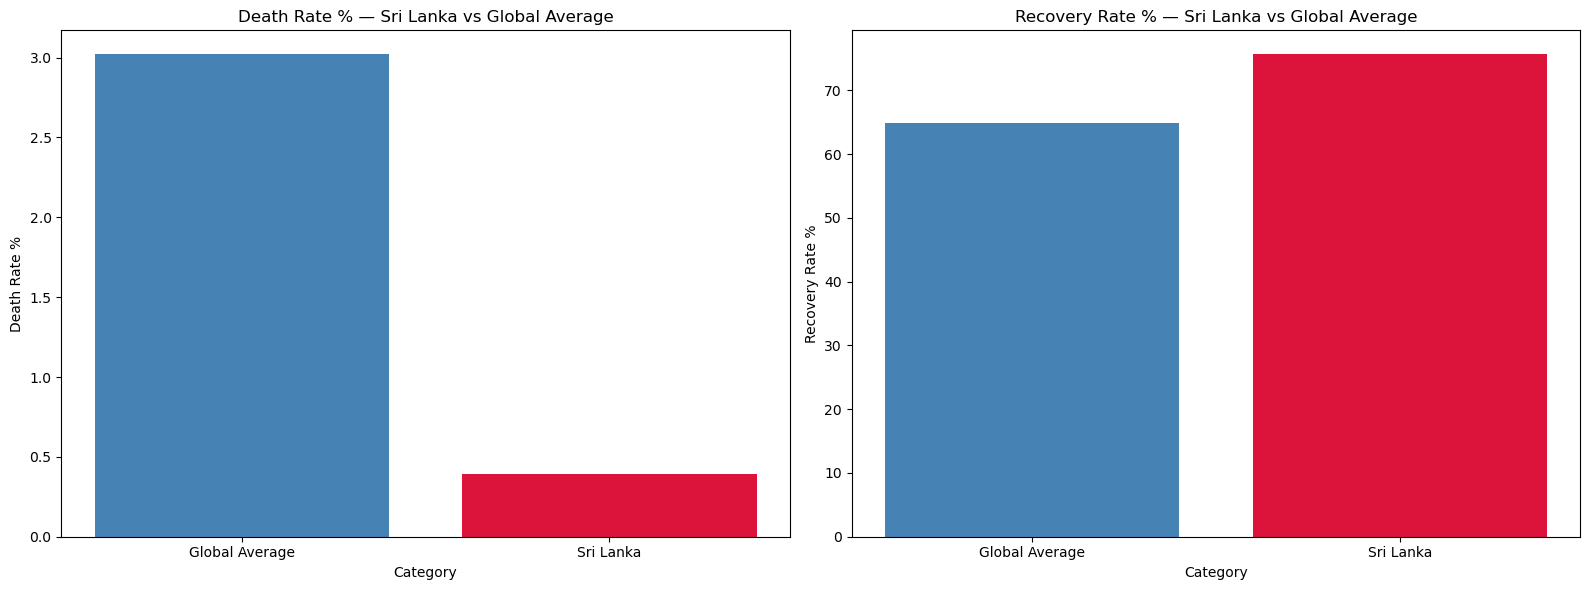

In [101]:
comparision = pd.DataFrame({
    'Category' : ['Global Average', 'Sri Lanka'],
    'Death Rate %' : [df['Deaths / 100 Cases'].mean().round(2) ,0.39], 'Recovery Rate %': [df['Recovered / 100 Cases'].mean().round(2),75.61]})

fig , (ax1,ax2) = plt.subplots(1,2,figsize = (16,6))

color = ['steelblue','crimson']

ax1.bar(comparision['Category'],comparision['Death Rate %'] ,color = color)
ax1.set_title('Death Rate % — Sri Lanka vs Global Average')
ax1.set_xlabel('Category')
ax1.set_ylabel('Death Rate %')

ax2.bar(comparision['Category'],comparision['Recovery Rate %'], color = color)
ax2.set_title('Recovery Rate % — Sri Lanka vs Global Average')
ax2.set_xlabel('Category')
ax2.set_ylabel('Recovery Rate %')

plt.tight_layout()
plt.show()